# FD004 Model Invariance Test

This notebook checks whether model outputs respond to **relevant** features and stay comparatively stable for **irrelevant** features.

Approach:
1. Estimate feature relevance using permutation importance on the test set.
2. Mark top features as relevant and bottom features as irrelevant.
3. Perturb both groups and compare prediction changes.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from model.lstm_model import LSTMRULModel

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(7)

In [2]:
ROOT = Path('.').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODEL_PATH = ROOT / 'model' / 'best_model.pth'
RUL_CAP = 125.0
DEVICE = torch.device('cpu')

with open(PROCESSED_DIR / 'feature_columns.json', 'r', encoding='utf-8') as fp:
    feature_columns = json.load(fp)

X_test = np.load(PROCESSED_DIR / 'X_test_last.npy').astype(np.float32)
y_test = np.load(PROCESSED_DIR / 'y_test_last.npy').astype(np.float32)

model = LSTMRULModel(input_size=X_test.shape[-1], hidden_size=128, num_layers=2, dropout=0.2).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print(f'Loaded {len(feature_columns)} features: {feature_columns}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

Loaded 15 features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'cycle_norm']
X_test shape: (248, 30, 15), y_test shape: (248,)


In [3]:
def predict_rul_cycles(x_np: np.ndarray) -> np.ndarray:
    x_tensor = torch.tensor(x_np, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        pred_norm = model(x_tensor).cpu().numpy()
    return pred_norm * RUL_CAP


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


subset_size = min(300, len(X_test))
subset_idx = rng.choice(len(X_test), size=subset_size, replace=False)
X_subset = X_test[subset_idx].copy()
y_subset = y_test[subset_idx].copy()

baseline_pred = predict_rul_cycles(X_subset)
baseline_rmse = rmse(y_subset, baseline_pred)
print(f'Baseline RMSE on subset ({subset_size} units): {baseline_rmse:.3f} cycles')

Baseline RMSE on subset (248 units): 81.393 cycles


In [4]:
importance_rows = []

for feat_idx, feat_name in enumerate(feature_columns):
    X_perm = X_subset.copy()
    shuffled_feature = X_perm[:, :, feat_idx].copy()
    rng.shuffle(shuffled_feature, axis=0)
    X_perm[:, :, feat_idx] = shuffled_feature

    perm_pred = predict_rul_cycles(X_perm)
    perm_rmse = rmse(y_subset, perm_pred)

    importance_rows.append(
        {
            'feature': feat_name,
            'perm_rmse': perm_rmse,
            'rmse_increase': perm_rmse - baseline_rmse,
        }
    )

importance_df = pd.DataFrame(importance_rows).sort_values('rmse_increase', ascending=False).reset_index(drop=True)
importance_df

,feature,perm_rmse,rmse_increase
0,cycle_norm,83.734688,2.341721
1,sensor_15,81.729401,0.336433
2,sensor_12,81.608757,0.215790
3,sensor_4,81.536835,0.143867
4,sensor_9,81.499023,0.106056
5,sensor_13,81.482643,0.089676
6,sensor_17,81.480865,0.087898
7,sensor_2,81.466614,0.073647
8,sensor_11,81.432205,0.039238
9,sensor_14,81.371185,-0.021782


In [5]:
top_k = 3
relevant_features = importance_df.head(top_k)['feature'].tolist()
irrelevant_features = importance_df.tail(top_k)['feature'].tolist()

relevant_idx = [feature_columns.index(f) for f in relevant_features]
irrelevant_idx = [feature_columns.index(f) for f in irrelevant_features]

print('Relevant features (most impact on RMSE when permuted):')
print(relevant_features)
print('\nIrrelevant features (least impact on RMSE when permuted):')
print(irrelevant_features)

Relevant features (most impact on RMSE when permuted):
['cycle_norm', 'sensor_15', 'sensor_12']

Irrelevant features (least impact on RMSE when permuted):
['sensor_20', 'sensor_8', 'sensor_7']


In [6]:
def perturb_and_measure(
    x_np: np.ndarray,
    feature_indices: list[int],
    baseline_prediction: np.ndarray,
    magnitude: float = 0.15,
    runs: int = 30,
) -> dict:
    delta_runs = []

    for _ in range(runs):
        x_mod = x_np.copy()

        signed_noise = magnitude * rng.choice(
            [-1.0, 1.0], size=(x_mod.shape[0], x_mod.shape[1], len(feature_indices))
        )
        x_mod[:, :, feature_indices] = np.clip(
            x_mod[:, :, feature_indices] + signed_noise,
            0.0,
            1.0,
        )

        pred_mod = predict_rul_cycles(x_mod)
        delta_runs.append(np.abs(pred_mod - baseline_prediction))

    delta_all = np.vstack(delta_runs)

    return {
        'mean_abs_delta': float(delta_all.mean()),
        'median_abs_delta': float(np.median(delta_all)),
        'p90_abs_delta': float(np.percentile(delta_all, 90)),
        'pct_ge_5_cycles': float((delta_all >= 5.0).mean() * 100.0),
        'raw_delta': delta_all,
    }


rel_metrics = perturb_and_measure(
    X_subset,
    relevant_idx,
    baseline_prediction=baseline_pred,
    magnitude=0.15,
    runs=30,
)

irr_metrics = perturb_and_measure(
    X_subset,
    irrelevant_idx,
    baseline_prediction=baseline_pred,
    magnitude=0.15,
    runs=30,
)

In [7]:
summary_df = pd.DataFrame(
    [
        {'group': 'Relevant perturbed', **{k: v for k, v in rel_metrics.items() if k != 'raw_delta'}},
        {'group': 'Irrelevant perturbed', **{k: v for k, v in irr_metrics.items() if k != 'raw_delta'}},
    ]
)

criteria = {
    'Relevant mean delta > 1.5x irrelevant mean delta': rel_metrics['mean_abs_delta'] > 1.5 * irr_metrics['mean_abs_delta'],
    'Irrelevant median delta < 2 cycles': irr_metrics['median_abs_delta'] < 2.0,
    'Relevant pct(|delta| >= 5) > Irrelevant pct(|delta| >= 5)': rel_metrics['pct_ge_5_cycles'] > irr_metrics['pct_ge_5_cycles'],
}
criteria_df = pd.DataFrame(
    [{'criterion': key, 'pass': value} for key, value in criteria.items()]
)

print('Invariance test summary metrics:')
display(summary_df)

print('Rule-based checks:')
display(criteria_df)

overall_pass = all(criteria.values())
overall_label = 'PASS' if overall_pass else 'FAIL'
print(f'Overall result: {overall_label}')

Invariance test summary metrics:


,group,mean_abs_delta,median_abs_delta,p90_abs_delta,pct_ge_5_cycles
0,Relevant perturbed,36.701050,18.883205,112.008934,77.02957
1,Irrelevant perturbed,0.613062,0.471014,1.333490,0.00000


Rule-based checks:


,criterion,pass
0,Relevant mean delta > 1.5x irrelevant mean delta,True
1,Irrelevant median delta < 2 cycles,True
2,Relevant pct(|delta| >= 5) > Irrelevant pct(|d...,True


Overall result: PASS


/var/folders/y3/nq41wqsn6877qhrzs07ytt2w0000gn/T/ipykernel_27730/495248908.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


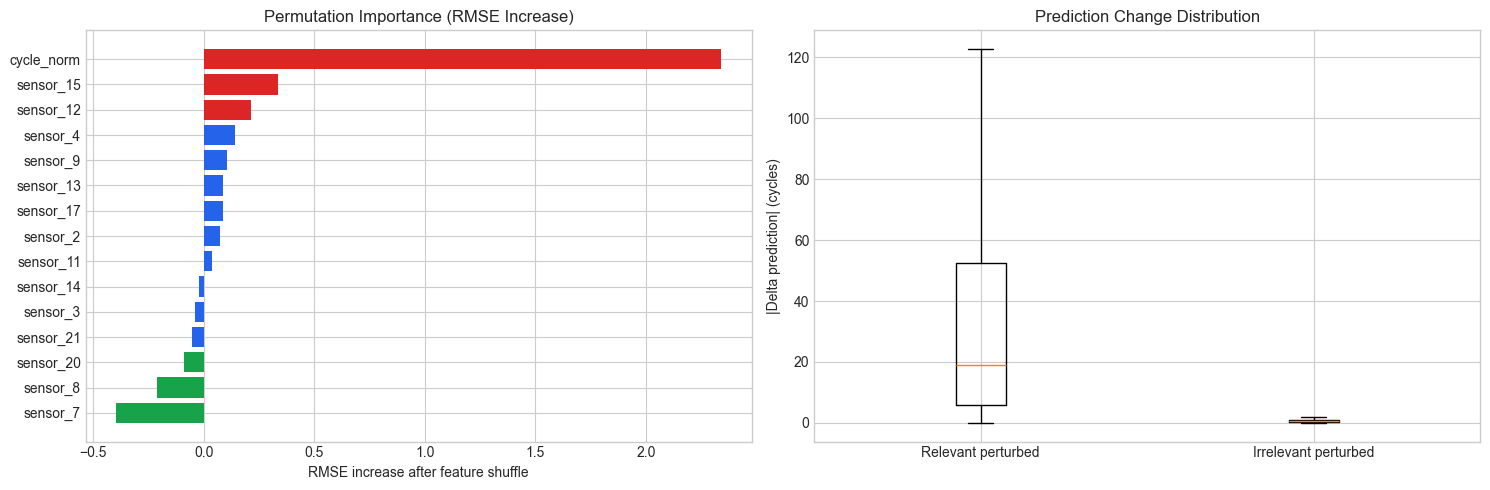

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

importance_plot_df = importance_df.sort_values('rmse_increase', ascending=True).copy()
colors = []
for feat in importance_plot_df['feature']:
    if feat in relevant_features:
        colors.append('#dc2626')
    elif feat in irrelevant_features:
        colors.append('#16a34a')
    else:
        colors.append('#2563eb')

axes[0].barh(importance_plot_df['feature'], importance_plot_df['rmse_increase'], color=colors)
axes[0].set_title('Permutation Importance (RMSE Increase)')
axes[0].set_xlabel('RMSE increase after feature shuffle')

axes[1].boxplot(
    [rel_metrics['raw_delta'].ravel(), irr_metrics['raw_delta'].ravel()],
    labels=['Relevant perturbed', 'Irrelevant perturbed'],
    showfliers=False,
)
axes[1].set_title('Prediction Change Distribution')
axes[1].set_ylabel('|Delta prediction| (cycles)')

plt.tight_layout()
plt.show()

## Interpretation

- If relevant-feature perturbations produce much larger prediction shifts, the model is responsive to important signals.
- If irrelevant-feature perturbations produce small shifts, the model shows practical invariance to low-importance inputs.
- If checks fail, consider retraining with stronger regularization or feature pruning.